<Axes: >

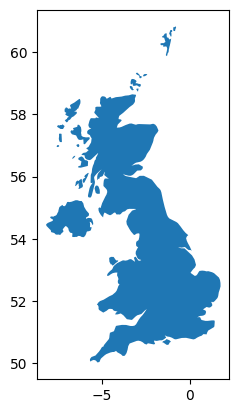

In [19]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(url)
uk = world[world["NAME"] == "United Kingdom"]
uk.plot()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_units = pd.read_csv("./Figure1_without_EV(2024)/1a_units.csv")
df_units = df_units.loc[:, ["type", "y", "x", "capacity"]]
geometry_units = gpd.points_from_xy(df_units.x, df_units.y)
geo_units_df = gpd.GeoDataFrame(df_units[["type", "y", "x", "capacity"]], geometry=geometry_units, crs="EPSG:4326")
geo_units_df.head()

,type,y,x,capacity,geometry
0,biomass,53.735800,-0.996389,2580.000000,POINT (-0.99639 53.7358)
1,biomass,57.480403,-3.603516,30.000000,POINT (-3.60352 57.4804)
2,biomass,51.459000,0.389000,44.000000,POINT (0.389 51.459)
3,biomass,53.748711,-0.626221,15.833333,POINT (-0.62622 53.74871)
4,biomass,53.748711,-0.626221,15.833333,POINT (-0.62622 53.74871)


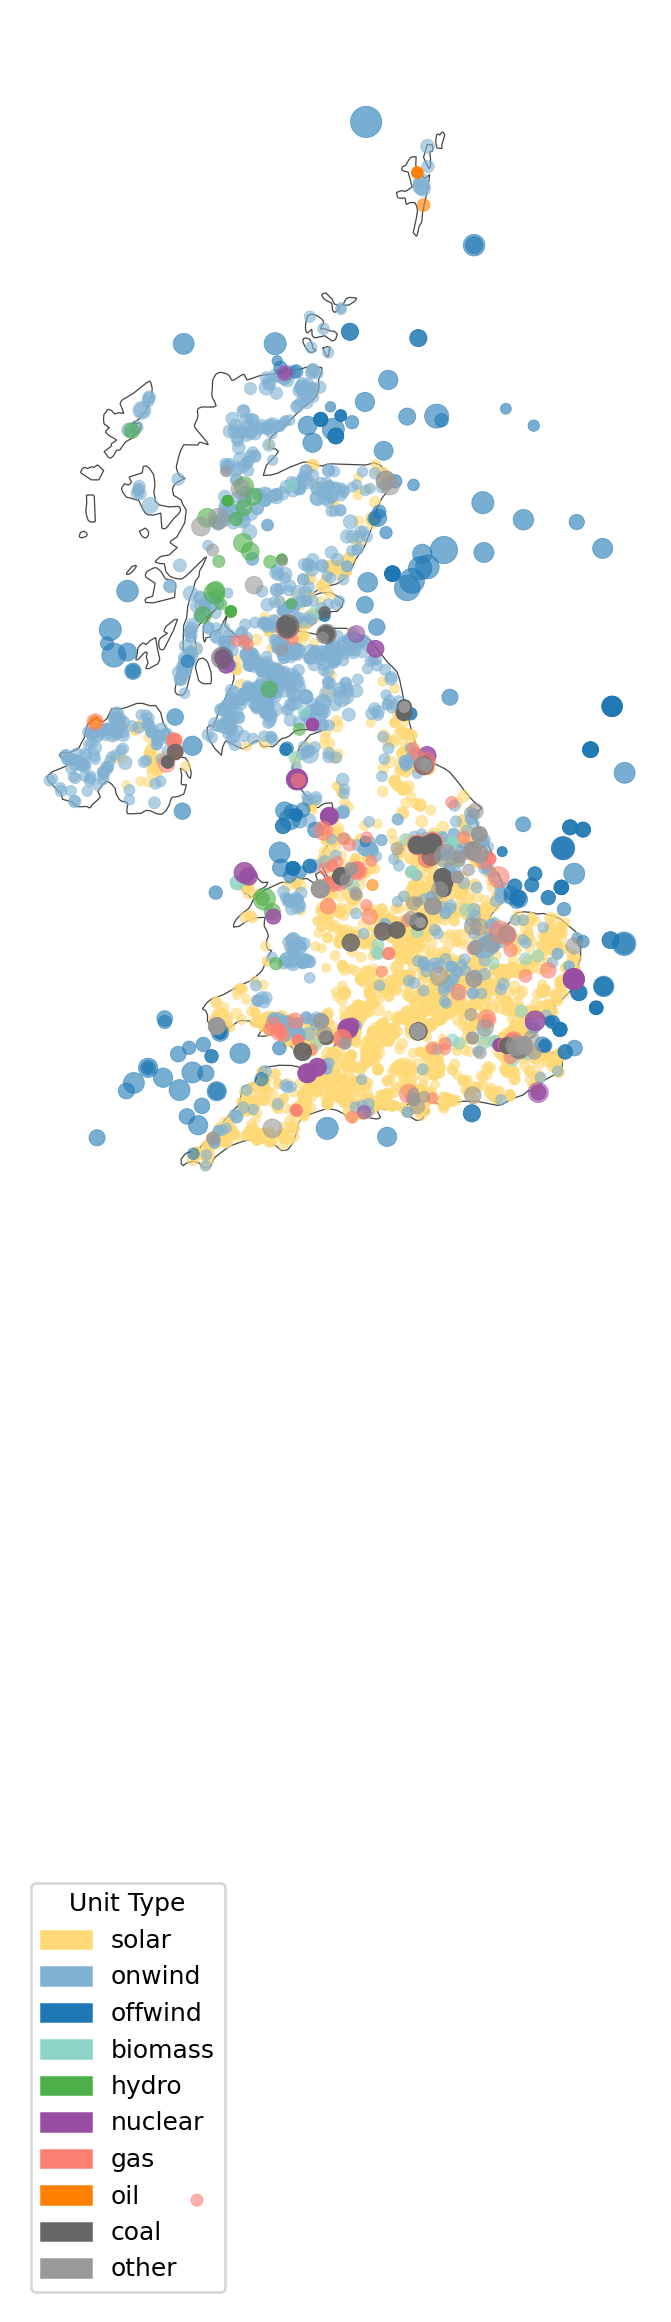

In [44]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from shapely.geometry import box
from matplotlib.lines import Line2D

# 1) 读取英国边界
url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(url)
uk_mask = False
for col in ["NAME", "ADMIN", "NAME_EN", "name"]:
    if col in world.columns:
        uk_mask = uk_mask | (world[col] == "United Kingdom")
uk = world[uk_mask].to_crs(epsg=4326)

# 2) 读取机组点
df = pd.read_csv("./Figure1_without_EV(2024)/1a_units.csv")
df = df.loc[:, ["type", "y", "x", "capacity"]]
pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["x"], df["y"]), crs="EPSG:4326")
pts = pts

# 3) 投影到 Web Mercator
uk_3857  = uk.to_crs(3857)
pts_3857 = pts.to_crs(3857)

# minx, miny, maxx, maxy = uk_3857.total_bounds
# bufx = (maxx - minx) * 0.3
# bufy = (maxy - miny) * 0.1
# bbox = box(minx - bufx, miny - bufy, maxx + bufx, maxy + bufy)
# bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs=uk_3857.crs)

# 4) 颜色表（和 folium 一致）
type_colors = {
    'biomass':  '#8dd3c7',
    'solar':    '#fed976',
    'onwind':   '#80b1d3',
    'offwind':  '#1f78b4',
    'nuclear':  '#984ea3',
    'hydro':    '#4daf4a',
    'coal':     '#666666',
    'gas':      '#fb8072',
    'oil':      '#ff7f00',
}

pts_3857["type_norm"] = pts_3857["type"].astype(str).str.strip().str.lower()
pts_3857.loc[~pts_3857["type_norm"].isin(type_colors), "type_norm"] = "other"

# 5) 点大小函数（可调参数增强对比）
def radius_from_cap(v):
    try:
        v = float(v)
        if v <= 0: return 3
        r = 3 + 0.6 * (v ** 0.3)        # 幂律缩放
        return float(np.clip(r, 3, 18)) # 限制范围
    except:
        return 5.0
    
# 6) 绘图
fig, ax = plt.subplots(figsize=(11, 13), dpi=180)
# # 背景灰色
# bbox_gdf.plot(ax=ax, color="#e6e6e6", edgecolor="none", zorder=0)

# 英国白色 + 边框
uk_3857.plot(ax=ax, color="white", edgecolor="#444444",
             linewidth=0.5, alpha=1.0, zorder=1)



# 想让谁“在下面”，就把它放到列表前面
cat_order = ['solar','onwind','offwind','biomass','hydro','nuclear','gas','oil','coal','other']

patches = []
for t in [c for c in cat_order if c in pts_3857['type_norm'].unique()]:
    color = type_colors.get(t, '#999999')
    sub = pts_3857[pts_3857['type_norm'] == t].copy()
    # 先画容量大的，再画小的 -> 小点更不容易被遮住
    sub['__cap__'] = pd.to_numeric(sub.get('capacity', np.nan), errors='coerce')
    sub = sub.sort_values('__cap__', ascending=False)

    sub_sizes = (sub['capacity'].apply(radius_from_cap))**2
    sub.plot(
        ax=ax,
        color=color,
        markersize=sub_sizes,
        alpha=0.6,          # 稍高透明度，减弱遮挡
        edgecolor=color,    # 边缘同色，柔和
        linewidth=0.3,
        zorder=10           # 也可按类别再细调 zorder
    )
    patches.append(mpatches.Patch(color=color, label=t))



ax.legend(handles=patches, title="Unit Type", loc="lower left", frameon=True)
ax.set_axis_off()
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("gb_units_static_noborder.png", dpi=300, bbox_inches="tight")
plt.show()


In [34]:
df_smr = pd.read_csv('data_merge.csv')
df_smr = df_smr.loc[:, ("type", "latitude", "longitude", "capacity_mw")]
geometry_smr = geopandas.points_from_xy(df_smr.longitude, df_smr.latitude)
geo_smr_df = geopandas.GeoDataFrame(df_smr[["type", "latitude", "longitude", "capacity_mw"]], geometry=geometry_smr)
geo_smr_df.head()

,type,latitude,longitude,capacity_mw,geometry
0,Hydro,32.3220,65.1190,33.00,POINT (65.119 32.322)
1,Hydro,34.5560,69.4787,66.00,POINT (69.4787 34.556)
2,Hydro,34.6410,69.7170,100.00,POINT (69.717 34.641)
3,Hydro,34.4847,70.3633,11.55,POINT (70.3633 34.4847)
4,Hydro,35.9416,68.7100,6.00,POINT (68.71 35.9416)


{'CCUS', 'Hydrogen', 'Interconnector', 'SMR', 'Biomass', 'Hydro'}


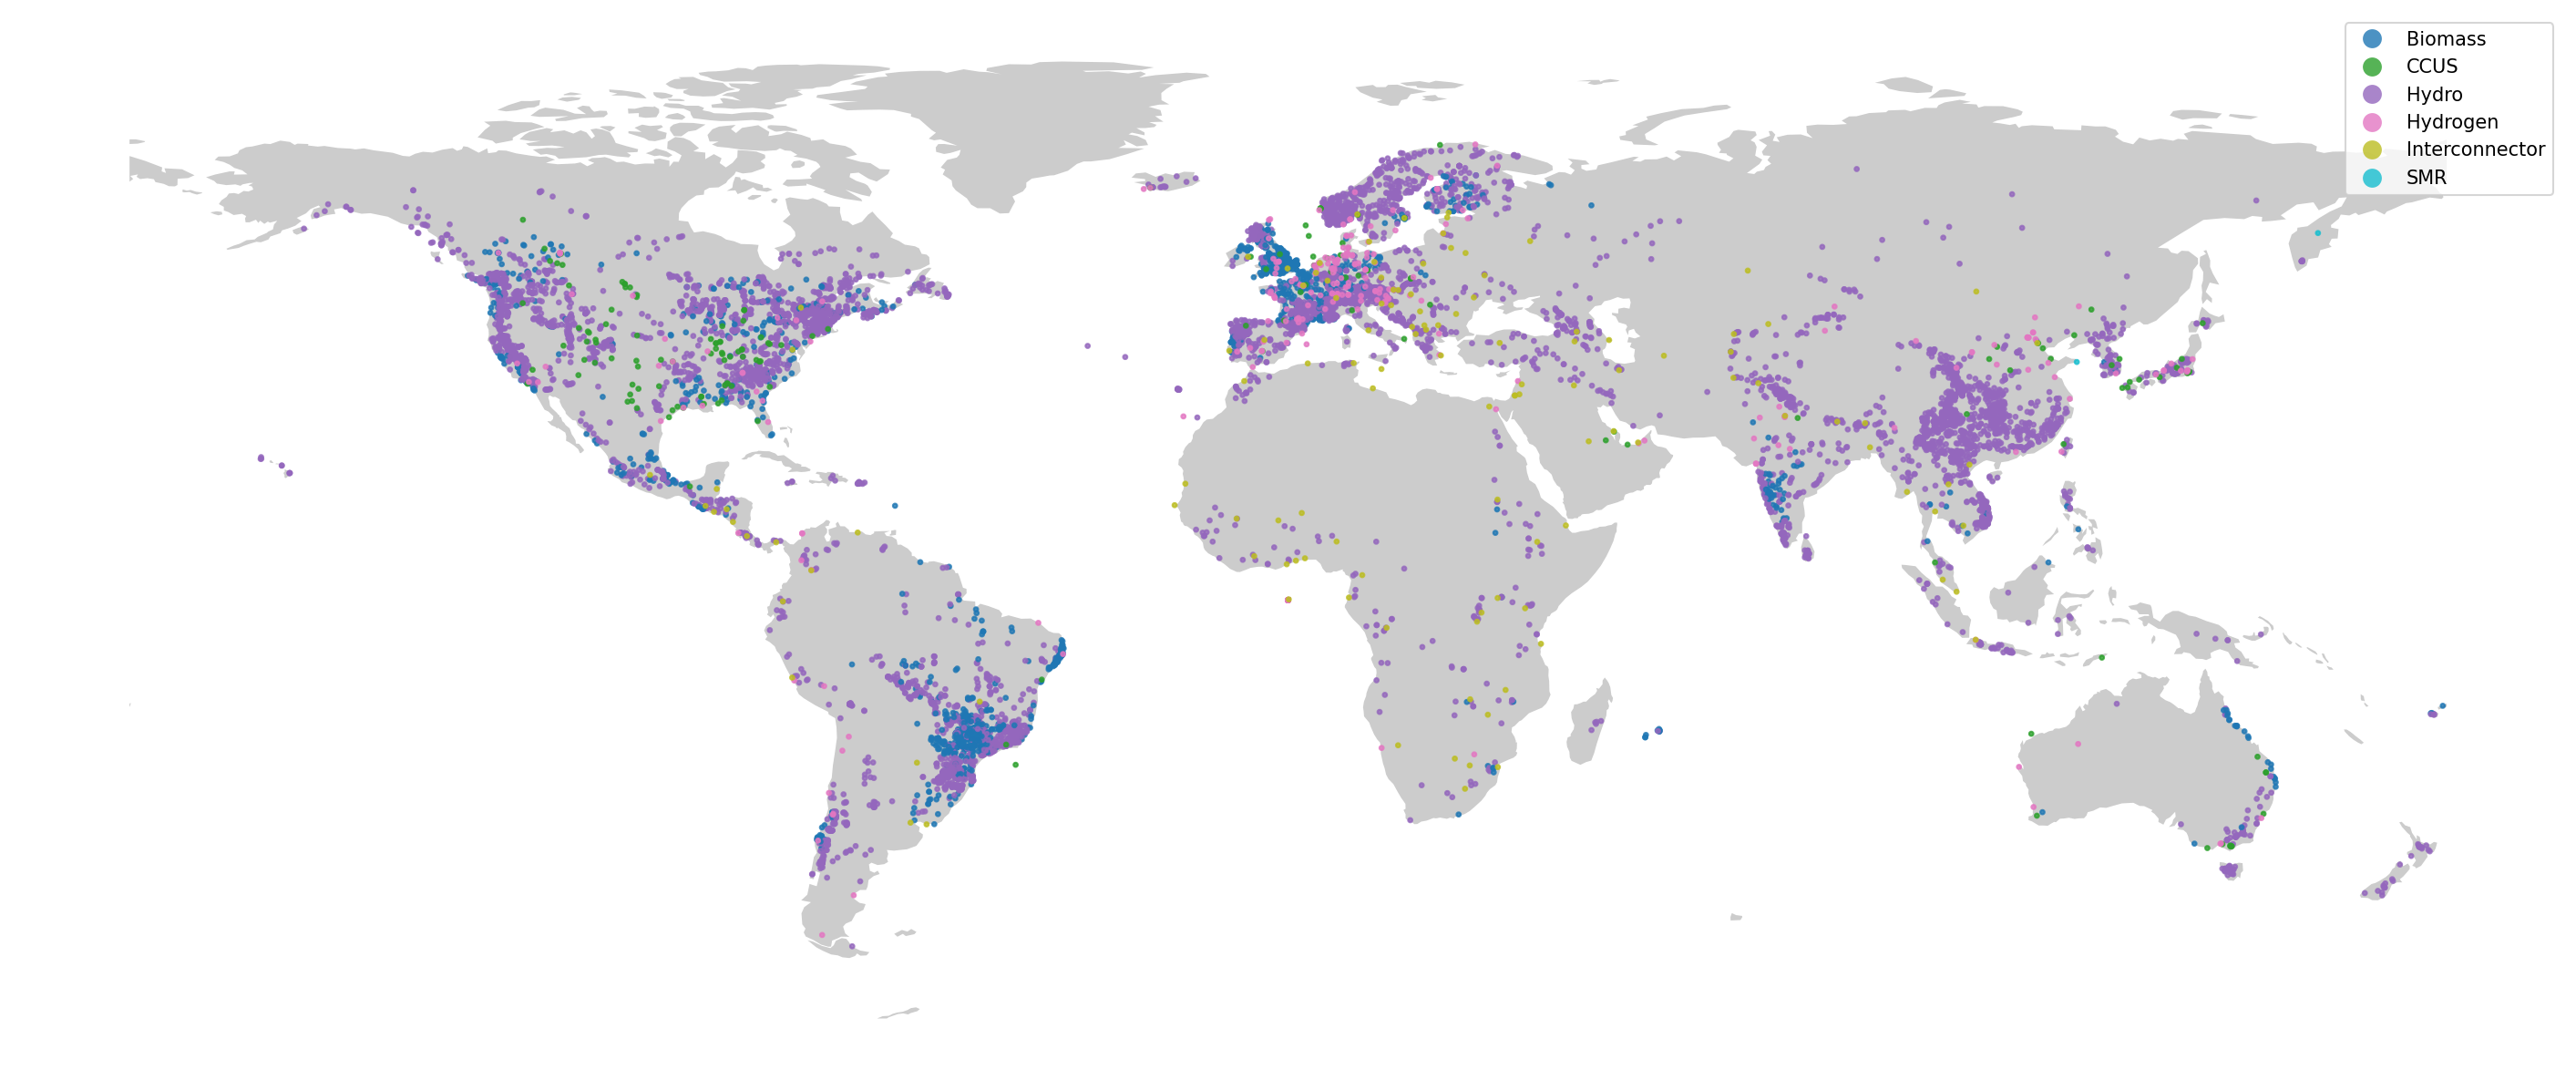

In [36]:
fig, ax = plt.subplots(figsize=(30, 10),dpi=150)
world.clip([-180, -65, 180, 90]).plot(ax=ax, alpha=0.4, color="grey")
#geo_smr_df.plot(ax=ax, color="red", legend=True, markersize=10, label="smr")
print(set(geo_smr_df['type']))
# geo_smr_1 = geo_smr_df.loc[geo_smr_df['type']=='CCUS']
geo_smr_df.plot(column="type", ax=ax, legend=True, markersize=5, alpha=0.8)

# plt.legend(loc="lower left")
ax.set_axis_off()
plt.show()

In [7]:
gen_map = folium.Map(
    max_bounds=True, 
    min_lat=-70,
    max_lat=70,
    min_lon=-150,
    max_lon=150,
    control_scale=False, # Show a scale on the bottom of the map
    zoom_control=False, # shows zoom buttons by default
    tiles="CartoDB positron")

In [26]:
folium.CircleMarker(
            location=[36.972222, 122.52889],
            radius=2,
            color="Green",
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(max_width=200)
        ).add_to(gen_map)

In [88]:
import pandas as pd
import folium

# 假设 df_smr 已经是一个包含以下列的 DataFrame：
# 'type' (类别), 'latitude' (纬度), 'longitude' (经度), 'capacity_mw' (功率)
# 示例：
#    type   latitude  longitude  capacity_mw
# 0  Hydro  32.322    65.119      33.0
# 1  Hydro  34.556    69.4787     66.0
# 2  Hydro  34.641    69.717      100.0
# 3  Hydro  34.4847   70.3633     11.55
# 4  Hydro  35.9416   68.71       6.0

import numpy as np

# 先算出每组的 min 和 max
grp = df_smr.groupby('type')['capacity_mw']
mins = grp.transform('min')
maxs = grp.transform('max')
ranges = maxs - mins

# 有效避免除以 0
df_smr['norm_capacity'] = np.where(
    ranges == 0,
    1.0,                          # 如果极差为 0，就给 1.0
    (df_smr['capacity_mw'] - mins) / ranges
)


# 2. 根据归一化后的值计算圆圈的半径（可根据实际需求调整 scale）
#    这里将归一化值映射到 [5, 20] 的半径范围
min_radius, max_radius = 1, 5

def scale_radius(norm_val):
    return min_radius + norm_val * (max_radius - min_radius)

df_smr['radius'] = df_smr['norm_capacity'].apply(scale_radius)

# 3. 为每个 type 分配一种颜色
base_colors = [
    'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred',
    'beige', 'darkblue', 'darkgreen', 'cadetblue', 'darkpurple',
    'white', 'pink', 'lightblue', 'lightgreen', 'gray', 'black', 'lightgray'
]
unique_types = df_smr['type'].unique()
type_colors = {t: base_colors[i % len(base_colors)] for i, t in enumerate(unique_types)}

# 4. 创建 Folium 地图
m = folium.Map(location=[0, 0], zoom_start=2)

# 5. 添加每个点到地图上
for _, row in df_smr.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['radius'],
        color=type_colors[row['type']],
        fill=True,
        fill_opacity=0.6,
        popup=(f"Type: {row['type']}<br>"
               f"Capacity (MW): {row['capacity_mw']}<br>"
               f"Normalized: {row['norm_capacity']:.2f}")
    ).add_to(m)

# 6. 保存为 HTML
output_path = 'interactive_map.html'
m.save(output_path)
print(f"Interactive map saved to {output_path}")

# 如果在 Jupyter Notebook 中运行，可直接显示：
# m

# 使用示例：
# if __name__ == '__main__':
#     df_smr = pd.read_csv('your_data.csv')
#     create_interactive_map(df_smr, 'map.html')


Interactive map saved to interactive_map.html


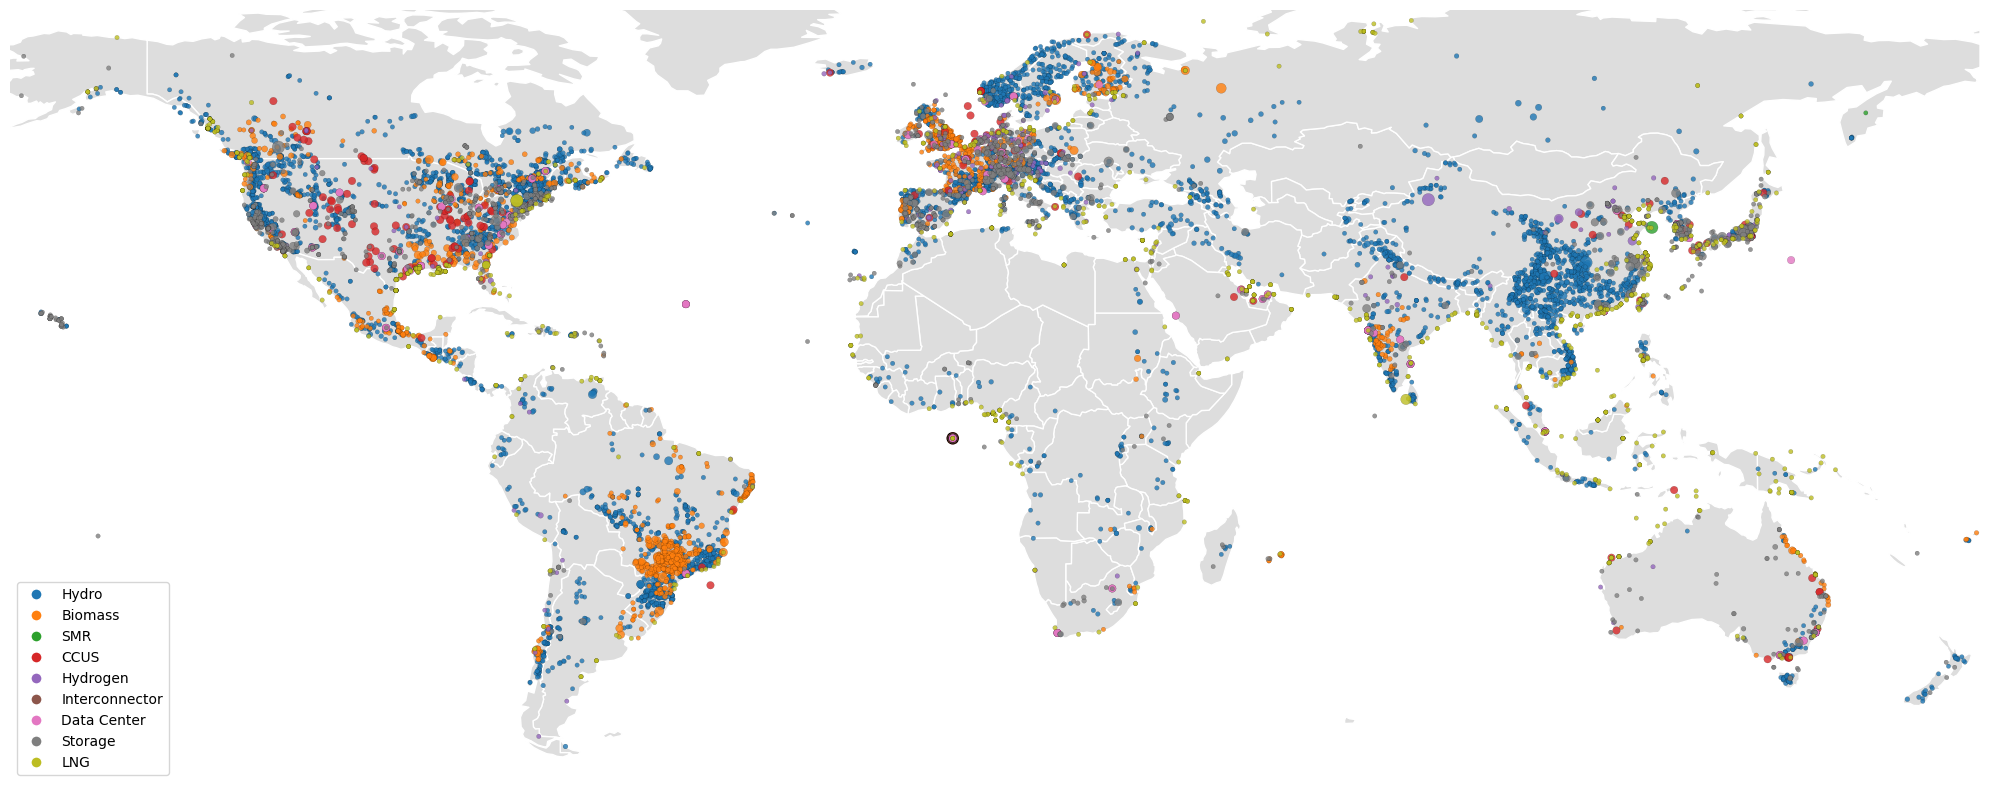

In [103]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ——— 1. 加载并准备数据 ———
# 如果你还没加载 df_smr，请取消下面一行注释并替换为你的文件路径：
# df_smr = pd.read_csv('your_data.csv')
df_smr = pd.read_csv('data_merge.csv')

# 定义一个安全的归一化函数，避免同一组中所有值都相同导致除以 0
def safe_normalize(x: pd.Series) -> pd.Series:
    rng = x.max() - x.min()
    if rng == 0:
        # 当组内所有 capacity_mw 相同，直接全部设为 1
        return pd.Series(1.0, index=x.index)
    else:
        return (x - x.min()) / rng

# 对每个 type 分组归一化 capacity_mw
df_smr['norm_capacity'] = (
    df_smr.groupby('type')['capacity_mw']
          .transform(safe_normalize)
)

# 映射归一化值到点的“面积”范围
min_area, max_area = 10, 80
df_smr['area'] = df_smr['norm_capacity'] * (max_area - min_area) + min_area
df_smr.loc[df_smr['type']=='CCUS','area'] = 30
df_smr.loc[df_smr['type']=='Data Center','area'] = 30

# ——— 2. 加载世界地图底图 ———
world_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/geojson/"
    "ne_110m_admin_0_countries.geojson"
)
world = gpd.read_file(world_url)

# ——— 3. 绘图 ———
fig, ax = plt.subplots(figsize=(20, 10))

# 底图：灰色填充，白色边界
world.plot(ax=ax, color='#dddddd', edgecolor='white')

# 限制显示经纬度范围，不显示南北极
ax.set_xlim(-165, 180)
ax.set_ylim(-60, 75)

# 准备每个类别的颜色
types = df_smr['type'].unique()
cmap = plt.get_cmap('tab10')
color_map = {t: cmap(i % 10) for i, t in enumerate(types)}

# 按类别画散点
for t in types:
    sub = df_smr[df_smr['type'] == t]
    ax.scatter(
        sub['longitude'], sub['latitude'],
        s=sub['area'],            # 面积
        c=[color_map[t]],         # 颜色
        alpha=0.8,
        label=t,
        linewidths=0.1,
        edgecolors='k'
    )

# 自定义图例
legend_elems = [
    Line2D([0], [0], marker='o', color='w',
           label=t, markerfacecolor=color_map[t],
           markersize=8)
    for t in types
]
ax.legend(handles=legend_elems, loc='lower left')

# ax.set_title('World Map of SMR Capacities\n(normalized size by type)')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('smr_world_map.png', dpi=300)
plt.show()


In [117]:
import pandas as pd
from pyecharts import options as opts
from pyecharts.charts import Geo
from pyecharts.globals import ChartType
# 从 global_options 导入 GeoOpts
from pyecharts.options.global_options import GeoOpts
from pyecharts.commons.utils import JsCode

# ——— 1. 读取数据 & 归一化 ———
df = pd.read_csv('data_merge.csv')

def safe_normalize(x: pd.Series) -> pd.Series:
    rng = x.max() - x.min()
    return pd.Series(1.0, index=x.index) if rng == 0 else (x - x.min()) / rng

# 分组归一化
df['norm_capacity'] = df.groupby('type')['capacity_mw'].transform(safe_normalize)
min_area, max_area = 10, 80
df['area'] = df['norm_capacity'] * (max_area - min_area) + min_area
# 固定大小
df.loc[df['type']=='CCUS', 'area'] = 30
df.loc[df['type']=='Data Center', 'area'] = 30

# ——— 2. 构建 Geo（世界轮廓），设置画布大小 ———
geo = (
    Geo(init_opts=opts.InitOpts(width="2000px", height="1000px"))
    .add_schema(
        maptype="world",
        itemstyle_opts=opts.ItemStyleOpts(
            area_color="#dddddd",
            border_color="white",
        ),
        label_opts=opts.LabelOpts(is_show=False),
        zoom=1.2,
        roam=True
    )
)

# ——— 3. 注册坐标 & 分组 ———
groups: dict[str, list[tuple[str, float]]] = {}
for idx, row in df.iterrows():
    name = f"{row['type']}_{idx}"
    geo.add_coordinate(name, row['longitude'], row['latitude'])
    groups.setdefault(row['type'], []).append((name, row['area']))

# 回调：取 val[2] 作为 symbol_size
size_func = JsCode("function (val) { return val[2]; }")

# ——— 4. 添加 scatter 系列 ———
for t, data_pair in groups.items():
    geo.add(
        series_name=t,
        data_pair=data_pair,
        type_=ChartType.SCATTER,
        symbol_size=size_func,
        label_opts=opts.LabelOpts(is_show=False),
    )

# ——— 5. 全局配置：禁用缩放，仅允许平移 & 渲染 ———
geo.set_global_opts(
    title_opts=opts.TitleOpts(
        title="SMR Capacities on World Map",
        subtitle="circle size ∼ normalized capacity by type",
        pos_left="center",
    ),
    legend_opts=opts.LegendOpts(pos_left="left", pos_top="bottom"),
    geo_opts=GeoOpts(
        zoom=1.2,
        roam="move"  # 仅允许平移，禁止缩放
    )
)

# 输出 HTML
geo.render('smr_world_map.html')
print("已生成：smr_world_map.html（仅允许平移，禁止缩放）")


ImportError: cannot import name 'GeoOpts' from 'pyecharts.options.global_options' (/Users/panzhanhua/opt/miniconda3_arm64/lib/python3.12/site-packages/pyecharts/options/global_options.py)